In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [6]:

dataset1 = pd.read_csv('Salary_Data.csv')
X = dataset1[['YearsExperience']].values
y = dataset1[['Salary']].values


In [20]:
print("Name:Somalaraju Rohini")
print("Register Number:212224240156")
dataset1.info()

Name:Somalaraju Rohini
Register Number:212224240156
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=33)

In [8]:

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)


In [10]:
# Name:Somalaraju Rohini
# Register Number:212224240156
class NeuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Simple Feedforward Network
        self.fc1 = nn.Linear(1, 10)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(10, 1)

        # Store training history
        self.history = {'loss': []}

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

In [11]:
# Initialize the Model, Loss Function, and Optimizer
ai_brain = NeuralNet()
criterion = nn.MSELoss()
optimizer = optim.Adam(ai_brain.parameters(), lr=0.01)

In [12]:
# Name: Somalaraju Rohini
# Register Number:212224240156
def train_model(ai_brain, X_train, y_train, criterion, optimizer, epochs=2000):
    for epoch in range(epochs):
        # Forward pass
        outputs = ai_brain(X_train)
        loss = criterion(outputs, y_train)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Store loss
        ai_brain.history['loss'].append(loss.item())

        if epoch % 200 == 0:
            print(f'Epoch [{epoch}/{epochs}], Loss: {loss.item():.6f}')

In [13]:
train_model(ai_brain, X_train_tensor, y_train_tensor, criterion, optimizer)

Epoch [0/2000], Loss: 6374433280.000000
Epoch [200/2000], Loss: 6362631168.000000
Epoch [400/2000], Loss: 6318940672.000000
Epoch [600/2000], Loss: 6247084544.000000
Epoch [800/2000], Loss: 6150159360.000000
Epoch [1000/2000], Loss: 6030894080.000000
Epoch [1200/2000], Loss: 5891822080.000000
Epoch [1400/2000], Loss: 5735317504.000000
Epoch [1600/2000], Loss: 5563607552.000000
Epoch [1800/2000], Loss: 5378771456.000000


In [14]:

with torch.no_grad():
    test_loss = criterion(ai_brain(X_test_tensor), y_test_tensor)
    print(f'Test Loss: {test_loss.item():.6f}')


Test Loss: 5503974912.000000


In [15]:
loss_df = pd.DataFrame(ai_brain.history)

Name:Somalaraju Rohini
Register Number:212224240156


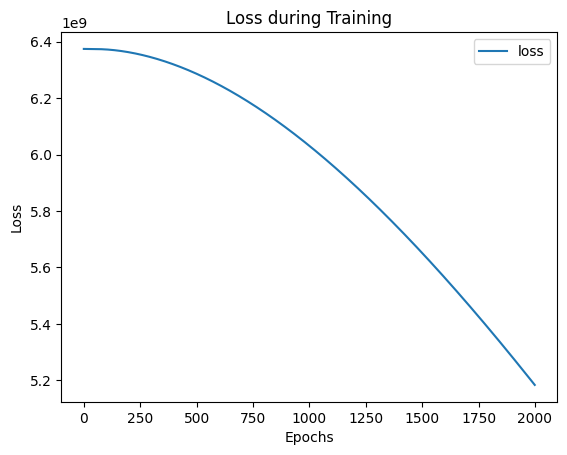

In [18]:
import matplotlib.pyplot as plt
loss_df.plot()
print("Name:Somalaraju Rohini")
print("Register Number:212224240156")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss during Training")
plt.show()


In [19]:

X_n1_1 = torch.tensor([[9]], dtype=torch.float32)
prediction = ai_brain(torch.tensor(scaler.transform(X_n1_1), dtype=torch.float32)).item()
print("Name:Somalaraju Rohini")
print("Register Number:212224240156")
print(f'Prediction: {prediction}')

Name:Somalaraju Rohini
Register Number:212224240156
Prediction: 10007.458984375
